In [34]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from uncertainties import ufloat
from uncertainties import unumpy
from ctypes import c_double
from pathlib import Path
import pickle

# import ROOT
# ROOT.EnableImplicitMT()    # Tells ROOT to go parallel

### all background

In [39]:
HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_1111best_valloss_epoch_MET400_multiplane_dphi_test3/tables')
TABLE = 'gridsearch_disco.pkl'
PLANEs = ['CP0', 'CP1', 'CP2', 'CP3']
sample = 'C1N2ML_M500_485_ct20_2018'
tables = {}

def get_table(sample, plane, isData=False):
    SAMPLE = f'{sample}_{plane}_evt_leading_vtx_{plane}_dphiMET_vs_{plane}_Max_ML_score'
    if isData: SAMPLE += '_withdata'
    
    TABLE_PATH = HISTDIR / SAMPLE / TABLE
    with open(TABLE_PATH, 'rb') as f:
        table = pickle.load(f)
    return table


for PLANE in PLANEs:
    table = get_table(sample, PLANE, isData=False)
    tables[PLANE] = table

In [40]:
loCut_key = '0.00,0.00'

any_PLANE = PLANEs[0]
table_keys = ['bkg_NA', 'bkg_NB', 'bkg_NC', 'bkg_ND']
any_key = table_keys[0]
indices = tables[any_PLANE][loCut_key][any_key].index
columns = tables[any_PLANE][loCut_key][any_key].columns

region_arrays = {}
tfs = {}

eps = 1e-8

for PLANE in PLANEs:
    print('PLANE:', PLANE)
    for table_key in table_keys:
        region_arrays[table_key] = unumpy.uarray(eps + tables[PLANE][loCut_key][table_key],
                                                 eps + tables[PLANE][loCut_key][f'{table_key}_unc'])
        
    tfs[PLANE + '_A/B'] = pd.DataFrame(region_arrays['bkg_NA'] / region_arrays['bkg_NB'], index=indices, columns=columns)
    tfs[PLANE + '_C/D'] = pd.DataFrame(region_arrays['bkg_NC'] / region_arrays['bkg_ND'], index=indices, columns=columns)

PLANE: CP0
PLANE: CP1
PLANE: CP2
PLANE: CP3


In [41]:
xcut = 1.5
ycut = 0.79
for k,v in tfs.items():
    print(k, ': ', v.loc[xcut, ycut])

CP0_A/B :  0.97+/-0.09
CP0_C/D :  1.223+/-0.014
CP1_A/B :  0.91+/-0.07
CP1_C/D :  1.105+/-0.012
CP2_A/B :  1.32+/-0.11
CP2_C/D :  1.032+/-0.016
CP3_A/B :  1.48+/-0.33
CP3_C/D :  0.90+/-0.07


In [43]:
HISTDIR = Path('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/vtx_PART_1111best_valloss_epoch_MET400_multiplane_dphi_test3/tables')
TABLE = 'gridsearch_disco.pkl'
PLANEs = ['CP0', 'CP1', 'CP2', 'CP3']
sample = 'C1N2ML_M500_485_ct20_2018'
tables_data = {}


for PLANE in PLANEs:
    table = get_table(sample, PLANE, isData=True)
    tables_data[PLANE] = table


any_PLANE = PLANEs[0]
table_keys = ['bkg_NA', 'bkg_NB', 'bkg_NC', 'bkg_ND']
any_key = table_keys[0]
indices = tables_data[any_PLANE][loCut_key][any_key].index
columns = tables_data[any_PLANE][loCut_key][any_key].columns

region_arrays = {}
tfs_data = {}

eps = 1e-8

for PLANE in PLANEs:
    print('PLANE:', PLANE)
    for table_key in table_keys:
        region_arrays[table_key] = unumpy.uarray(eps + tables_data[PLANE][loCut_key][table_key],
                                                 eps + tables_data[PLANE][loCut_key][f'{table_key}_unc'])
        
    tfs_data[PLANE + '_A/B'] = pd.DataFrame(region_arrays['bkg_NA'] / region_arrays['bkg_NB'], index=indices, columns=columns)
    tfs_data[PLANE + '_C/D'] = pd.DataFrame(region_arrays['bkg_NC'] / region_arrays['bkg_ND'], index=indices, columns=columns)

PLANE: CP0
PLANE: CP1
PLANE: CP2
PLANE: CP3


In [44]:
xcut = 1.5
ycut = 0.795
for k,v in tfs.items():
    print(k, ': ', v.loc[xcut, ycut])

CP0_A/B :  0.93+/-0.10
CP0_C/D :  1.222+/-0.014
CP1_A/B :  0.86+/-0.11
CP1_C/D :  1.104+/-0.012
CP2_A/B :  1.22+/-0.14
CP2_C/D :  1.034+/-0.016
CP3_A/B :  1.5+/-0.5
CP3_C/D :  0.91+/-0.07


In [45]:
xcut = 1.5
ycut = 0.795
for k,v in tfs_data.items():
    print(k, ': ', v.loc[xcut, ycut])

CP0_A/B :  1.11+/-0.08
CP0_C/D :  1.203+/-0.005
CP1_A/B :  1.00+/-0.06
CP1_C/D :  1.126+/-0.005
CP2_A/B :  1.00+/-0.09
CP2_C/D :  1.074+/-0.008
CP3_A/B :  1.22+/-0.32
CP3_C/D :  1.05+/-0.04


In [46]:
# xcut = 1.5
# ycut = 0.795

# ys, yerrs = [], []

# for k,v in tfs.items():
#     ys.append(v.loc[xcut, ycut].n)
#     yerrs.append(v.loc[xcut, ycut].s)

# xs = [0,0.5, 3,3.5, 6,6.5, 9,9.5] 

# plt.errorbar(xs[::2], ys[::2], yerrs[::2], color='orange', capsize=3, elinewidth=1, markersize=5, fmt='o', label="A/B")
# plt.errorbar(xs[1::2], ys[1::2], yerrs[1::2], color='indigo', capsize=3, elinewidth=1, markersize=5, fmt='o', label="C/D")
# plt.legend(loc='upper left')
# xtick_pos = [(xs[i] + xs[i+1])/2 for i in range(0, len(xs), 2)]
# xtick_labels = ['CP0', 'CP1', 'CP2', 'CP3']
# plt.xticks(xtick_pos, xtick_labels)
# plt.ylabel('Ratio of the yields')
# plt.title('MC')
# plt.show()

In [47]:
xcut = 1.5
ycut = 0.795

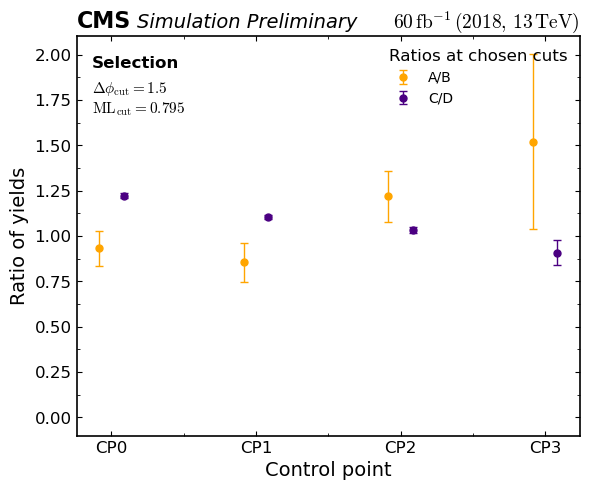

In [48]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

import matplotlib.pyplot as plt

# --- CMS/HEP-ish global style (matching your example vibe) ---
plt.rcParams.update({
    "figure.figsize": (6, 5),
    "axes.linewidth": 1.2,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "mathtext.fontset": "cm",
})

xcut = 1.5
ycut = 0.795

ys, yerrs = [], []
for k, v in tfs.items():
    ys.append(v.loc[xcut, ycut].n)
    yerrs.append(v.loc[xcut, ycut].s)

xs = [0, 0.5, 3, 3.5, 6, 6.5, 9, 9.5]

fig, ax = plt.subplots()

# Errorbars
ax.errorbar(xs[::2], ys[::2], yerrs[::2],
            color='orange', capsize=3, elinewidth=1.0, markersize=5,
            fmt='o', label="A/B")

ax.errorbar(xs[1::2], ys[1::2], yerrs[1::2],
            color='indigo', capsize=3, elinewidth=1.0, markersize=5,
            fmt='o', label="C/D")

# CP ticks at midpoints
xtick_pos = [(xs[i] + xs[i+1]) / 2 for i in range(0, len(xs), 2)]
ax.set_xticks(xtick_pos)
ax.set_xticklabels(['CP0', 'CP1', 'CP2', 'CP3'])

# Labels
ax.set_xlabel("Control point")
ax.set_ylabel("Ratio of yields")

# Minor ticks (CMS-ish)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

# Helpful ratio reference line
ax.axhline(2.0, color="black", linestyle="--", linewidth=1.0, alpha=0.)
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0, alpha=0.)

# --- 1) Text box (split header/body like your example) ---
ax.text(
    0.03, 0.95, "Selection",
    transform=ax.transAxes, fontsize=12, weight="bold",
    va="top"
)

ax.text(
    0.03, 0.89,
    rf"$\Delta \phi_\text{{cut}} = {xcut}$" + "\n" + rf"$\text{{ML}}_\text{{cut}} = {ycut}$",
    transform=ax.transAxes, fontsize=11, va="top"
)

# --- 2) CMS-like title (split bold/italic) ---
ax.text(
    0.0, 1.02, "CMS",
    transform=ax.transAxes, fontsize=16, weight="bold",
    ha="left", va="baseline"
)

ax.text(
    0.12, 1.02, "Simulation Preliminary",
    transform=ax.transAxes, fontsize=14, style="italic",
    ha="left", va="baseline"
)

ax.text(
    1.00, 1.02, r"$60 \, \text{fb}^{-1} \, (2018, \, 13 \, \text{TeV})$",
    transform=ax.transAxes, fontsize=14, style="italic",
    ha="right", va="baseline"
)

# --- 3) Legend (with a title, aligned left) ---
ax.legend(
    title="Ratios at chosen cuts",
    frameon=False,
    loc="upper right",
    alignment="left",
    title_fontproperties={"size": 12},
)

plt.tight_layout()
plt.show()


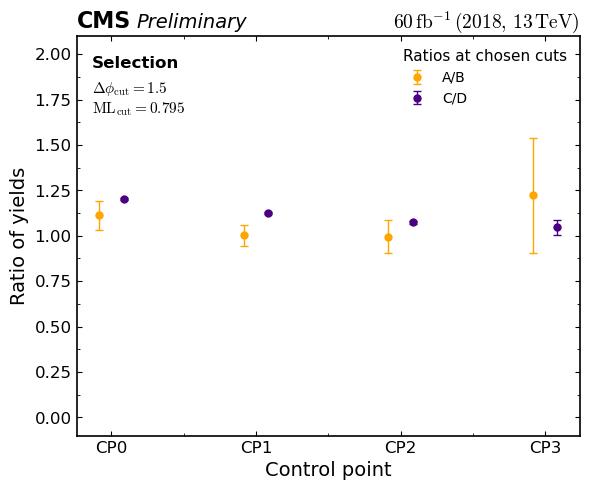

In [49]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

import matplotlib.pyplot as plt

# --- CMS/HEP-ish global style (matching your example vibe) ---
plt.rcParams.update({
    "figure.figsize": (6, 5),
    "axes.linewidth": 1.2,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "mathtext.fontset": "cm",
})

ys, yerrs = [], []
for k, v in tfs_data.items():
    ys.append(v.loc[xcut, ycut].n)
    yerrs.append(v.loc[xcut, ycut].s)

xs = [0, 0.5, 3, 3.5, 6, 6.5, 9, 9.5]

fig, ax = plt.subplots()

# Errorbars
ax.errorbar(xs[::2], ys[::2], yerrs[::2],
            color='orange', capsize=3, elinewidth=1.0, markersize=5,
            fmt='o', label="A/B")

ax.errorbar(xs[1::2], ys[1::2], yerrs[1::2],
            color='indigo', capsize=3, elinewidth=1.0, markersize=5,
            fmt='o', label="C/D")

# CP ticks at midpoints
xtick_pos = [(xs[i] + xs[i+1]) / 2 for i in range(0, len(xs), 2)]
ax.set_xticks(xtick_pos)
ax.set_xticklabels(['CP0', 'CP1', 'CP2', 'CP3'])

# Labels
ax.set_xlabel("Control point")
ax.set_ylabel("Ratio of yields")

# Minor ticks (CMS-ish)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

# Helpful ratio reference line
ax.axhline(2.0, color="black", linestyle="--", linewidth=1.0, alpha=0.)
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0, alpha=0.)

# --- 1) Text box (split header/body like your example) ---
ax.text(
    0.03, 0.95, "Selection",
    transform=ax.transAxes, fontsize=12, weight="bold",
    va="top"
)

ax.text(
    0.03, 0.89,
    rf"$\Delta \phi_\text{{cut}} = {xcut}$" + "\n" + rf"$\text{{ML}}_\text{{cut}} = {ycut}$",
    transform=ax.transAxes, fontsize=11, va="top"
)

# --- 2) CMS-like title (split bold/italic) ---
ax.text(
    0.0, 1.02, "CMS",
    transform=ax.transAxes, fontsize=16, weight="bold",
    ha="left", va="baseline"
)

ax.text(
    0.12, 1.02, "Preliminary",
    transform=ax.transAxes, fontsize=14, style="italic",
    ha="left", va="baseline"
)

ax.text(
    1.00, 1.02, r"$60 \, \text{fb}^{-1} \, (2018, \, 13 \, \text{TeV})$",
    transform=ax.transAxes, fontsize=14, style="italic",
    ha="right", va="baseline"
)

# --- 3) Legend (with a title, aligned left) ---
ax.legend(
    title="Ratios at chosen cuts",
    frameon=False,
    loc="upper right",
    alignment="left",
    title_fontproperties={"size": 11},
)

plt.tight_layout()
plt.show()


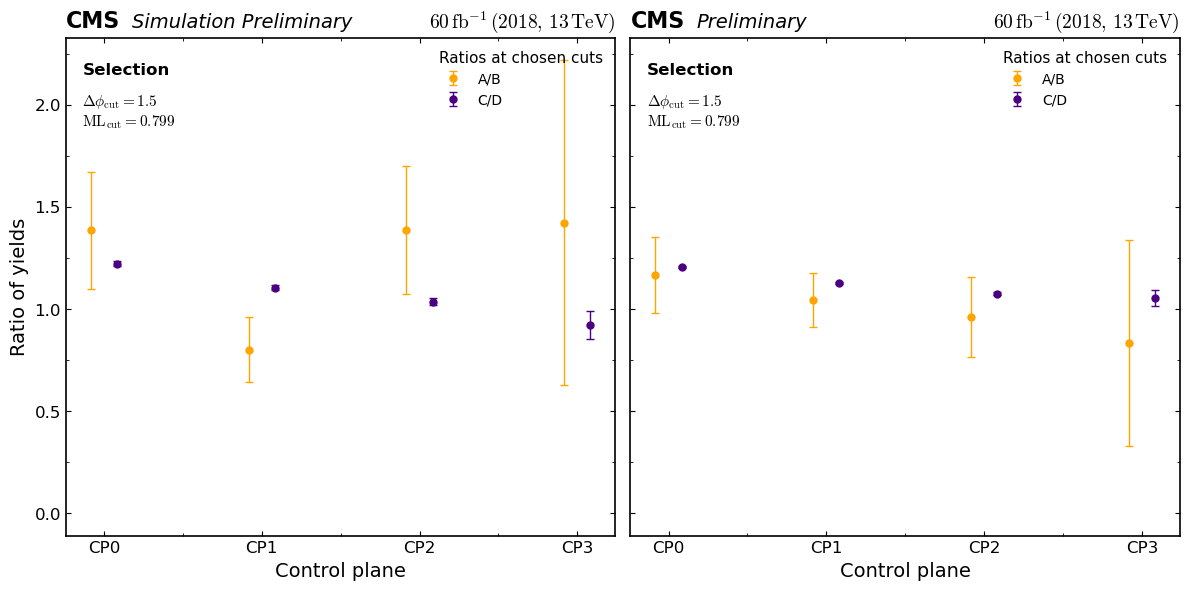

In [56]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# --- CMS/HEP-ish global style (set once) ---
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.linewidth": 1.2,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "mathtext.fontset": "cm",
})

def plot_panel(ax, tfs_like, xcut, ycut, left_italic, lumi_text, legend_title):
    # collect values
    ys, yerrs = [], []
    for _, v in tfs_like.items():
        ys.append(v.loc[xcut, ycut].n)
        yerrs.append(v.loc[xcut, ycut].s)

    xs = [0, 0.5, 3, 3.5, 6, 6.5, 9, 9.5]
    xtick_pos = [(xs[i] + xs[i+1]) / 2 for i in range(0, len(xs), 2)]
    xtick_labels = ['CP0', 'CP1', 'CP2', 'CP3']

    # errorbars
    ax.errorbar(xs[::2], ys[::2], yerrs[::2],
                color='orange', capsize=3, elinewidth=1.0, markersize=5,
                fmt='o', label="A/B")
    ax.errorbar(xs[1::2], ys[1::2], yerrs[1::2],
                color='indigo', capsize=3, elinewidth=1.0, markersize=5,
                fmt='o', label="C/D")

    # ticks/labels
    ax.set_xticks(xtick_pos)
    ax.set_xticklabels(xtick_labels)
    ax.set_xlabel("Control plane")

    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    # reference lines (ratios)
    ax.axhline(2.0, color="black", linestyle="--", linewidth=1.0, alpha=0.)
    ax.axhline(0., color="black", linestyle="--", linewidth=1.0, alpha=0.)

    # selection box
    ax.text(0.03, 0.95, "Selection",
            transform=ax.transAxes, fontsize=12, weight="bold", va="top")
    ax.text(0.03, 0.89,
            rf"$\Delta \phi_\text{{cut}} = {xcut}$" + "\n" + rf"$\text{{ML}}_\text{{cut}} = {ycut}$",
            transform=ax.transAxes, fontsize=11, va="top")

    # CMS header (bold + italic) + lumi right
    ax.text(0.00, 1.02, "CMS",
            transform=ax.transAxes, fontsize=16, weight="bold",
            ha="left", va="baseline")
    ax.text(0.12, 1.02, left_italic,
            transform=ax.transAxes, fontsize=14, style="italic",
            ha="left", va="baseline")
    ax.text(1.00, 1.02, lumi_text,
            transform=ax.transAxes, fontsize=14, style="italic",
            ha="right", va="baseline")

    ax.legend(title=legend_title, frameon=False, loc="upper right",
              alignment="left", title_fontproperties={"size": 11})


# ---- inputs ----
xcut = 1.5
ycut = 0.799
lumi_text = r"$60 \, \mathrm{fb}^{-1} \, (2018, \, 13 \, \mathrm{TeV})$"

fig, (ax_mc, ax_data) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

plot_panel(ax_mc,   tfs,      xcut, ycut, "Simulation Preliminary", lumi_text, "Ratios at chosen cuts")
plot_panel(ax_data, tfs_data, xcut, ycut, "Preliminary",            lumi_text, "Ratios at chosen cuts")

ax_mc.set_ylabel("Ratio of yields")
ax_data.set_ylabel("")  # shared y

plt.tight_layout()
plt.show()


In [57]:
for k, v in tfs_data.items():
    print(k,v.loc[xcut, ycut])

CP0_A/B 1.17+/-0.19
CP0_C/D 1.203+/-0.005
CP1_A/B 1.04+/-0.13
CP1_C/D 1.126+/-0.005
CP2_A/B 0.96+/-0.19
CP2_C/D 1.074+/-0.008
CP3_A/B 0.8+/-0.5
CP3_C/D 1.05+/-0.04


### Closure Check

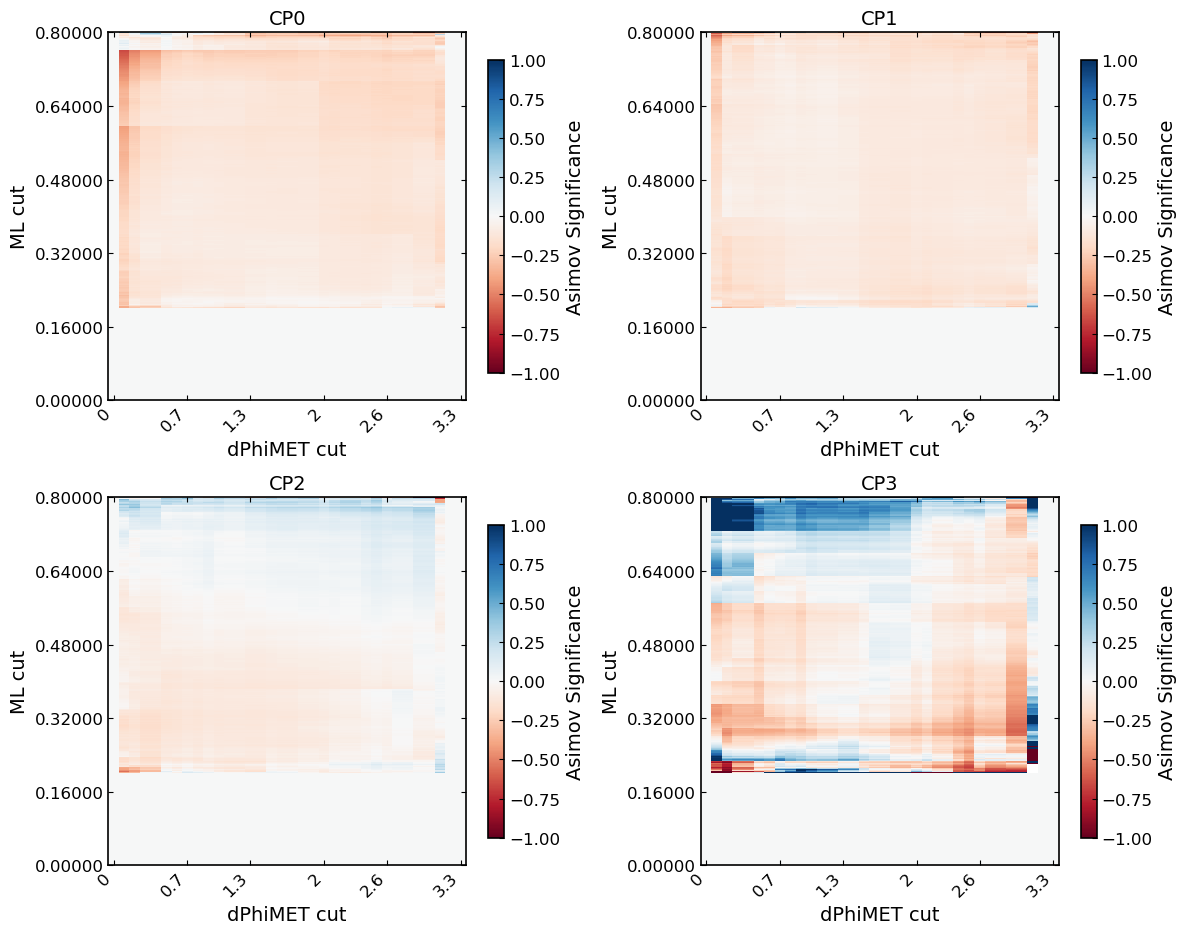

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

def pick_ticks(vals, n=6):
    vals = np.asarray(list(vals), dtype=float)
    if len(vals) <= n:
        return vals
    idx = np.unique(np.round(np.linspace(0, len(vals)-1, n)).astype(int))
    idx[0] = 0
    idx[-1] = len(vals) - 1
    return vals[idx]

def edges_from_centers(c):
    c = np.asarray(c, dtype=float)
    d = np.diff(c)
    e = np.empty(len(c) + 1)
    e[1:-1] = c[:-1] + d / 2
    e[0]  = c[0]  - d[0] / 2
    e[-1] = c[-1] + d[-1] / 2
    return e

def profile_x_mean_and_max(x, C):
    """
    For each y-bin (row of C), return:
      - x_mean(y): weighted mean of x using weights=C[y,x] (clipped to >=0), NaNs ignored
      - x_max(y): x position of maximum (argmax of weights), NaNs ignored
    C shape: (Ny, Nx), x shape: (Nx,)
    """
    x = np.asarray(x, dtype=float)
    C = np.asarray(C, dtype=float)

    w = np.where(np.isfinite(C), np.clip(C, 0.0, None), np.nan)  # keep NaN for max logic
    w0 = np.where(np.isfinite(w), w, 0.0)                        # for sums/means

    sw = w0.sum(axis=1)                                          # (Ny,)
    x_mean = np.divide((w0 * x[None, :]).sum(axis=1), sw,
                       out=np.full(C.shape[0], np.nan, dtype=float),
                       where=sw > 0)

    # max position per row (y)
    w_for_argmax = np.where(np.isfinite(w), w, -np.inf)
    imax = np.argmax(w_for_argmax, axis=1)                       # (Ny,)
    row_max = np.max(w_for_argmax, axis=1)
    x_max = np.where(np.isfinite(row_max) & (row_max > 0), x[imax], np.nan)

    return x_mean, x_max


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, ZK in zip(axes, PLANEs[:]):

    X_b = (tables[ZK]['0.00,0.00']['bkg_NA'] * 
           tables[ZK]['0.00,0.00']['bkg_ND'] / 
           tables[ZK]['0.00,0.00']['bkg_NC'] - tables[ZK]['0.00,0.00']['bkg_NB']) / \
           tables[ZK]['0.00,0.00']['bkg_NB']
    X_b = X_b.loc[0:, 0:0.80]
    X_b = X_b.fillna(0)

    x = X_b.index.to_numpy(dtype=float)
    y = X_b.columns.to_numpy(dtype=float)

    x_edges = edges_from_centers(x)
    y_edges = edges_from_centers(y)

    C = X_b.T.to_numpy()   # (Ny, Nx)
    absmax = np.nanmax(np.abs(C))

    pcm = ax.pcolormesh(
        x_edges, y_edges, C,
        cmap="RdBu",
        vmin=-1,
        vmax=1,
        shading="flat"
    )

    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))

    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()],
                       rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

    ax.set_xlabel("dPhiMET cut")
    ax.set_ylabel("ML cut")
    ax.set_title(ZK)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

    # ax.legend(frameon=False, loc="lower right")

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("Asimov Significance")

fig.suptitle('', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [58]:
tf_disagreements_n = {}
tf_disagreements_s = {}
for PLANE in PLANEs:
    tf_disagreement = tfs_data[PLANE + '_A/B'] - tfs_data[PLANE + '_C/D']
    tf_disagreements_n[PLANE] = tf_disagreement.map(lambda x: x.n)
    tf_disagreements_s[PLANE] = tf_disagreement.map(lambda x: x.s)

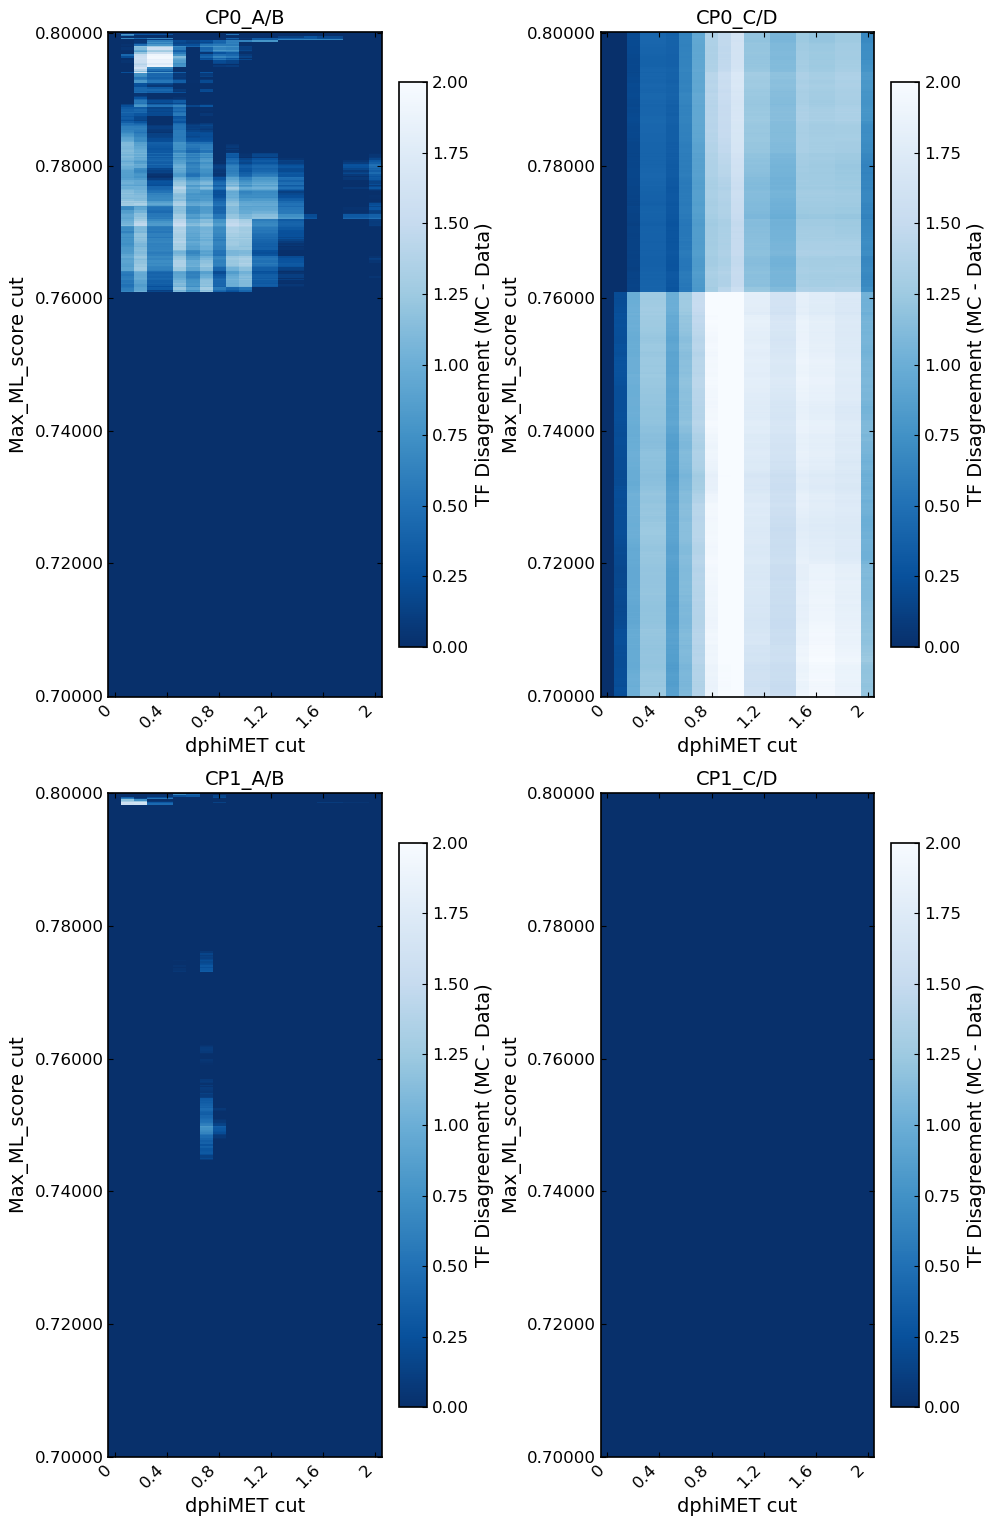

In [63]:
import matplotlib.ticker as mtick
def pick_ticks(vals, n=6):
    vals = np.asarray(list(vals), dtype=float)
    if len(vals) <= n:
        return vals
    idx = np.unique(np.round(np.linspace(0, len(vals)-1, n)).astype(int))
    idx[0] = 0
    idx[-1] = len(vals) - 1
    return vals[idx]

def edges_from_centers(c):
    c = np.asarray(c, dtype=float)
    d = np.diff(c)
    e = np.empty(len(c) + 1)
    e[1:-1] = c[:-1] + d / 2
    e[0]  = c[0]  - d[0] / 2
    e[-1] = c[-1] + d[-1] / 2
    return e

plotlim_xlo = 0.0
plotlim_xup = 2
plotlim_ylo = 0.7
plotlim_yup = 0.8

fig, axes = plt.subplots(2, 2, figsize=(10, 16))
axes = axes.flatten()

for ax, region in zip(axes, tf_disagreements_n.keys()):

    X_n = tf_disagreements_n[region]
    X_s = tf_disagreements_s[region]
    X   = X_n / X_s
    X_b = X.loc[plotlim_xlo:plotlim_xup, plotlim_ylo:plotlim_yup]
    X_b = X_b.fillna(0)

    x = X_b.index.to_numpy(dtype=float)
    y = X_b.columns.to_numpy(dtype=float)

    x_edges = edges_from_centers(x)
    y_edges = edges_from_centers(y)

    C = X_b.T.to_numpy()   # (Ny, Nx)
    absmax = np.nanmax(np.abs(C))

    pcm = ax.pcolormesh(
        x_edges, y_edges, C,
        cmap="Blues_r",
        vmin=0,
        vmax=2,
        shading="flat"
    )

    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))

    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()],
                       rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

    ax.set_xlabel(f'dphiMET cut')
    ax.set_ylabel(f'Max_ML_score cut')
    ax.set_title(region)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("TF Disagreement (MC - Data)")

# fig.suptitle(SAMPLE, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Data vs MC

In [60]:
tf_disagreements_n = {}
tf_disagreements_s = {}

for k in tfs.keys():
    tf_disagreement = tfs[k] - tfs_data[k]
    tf_disagreements_n[k] = tf_disagreement.map(lambda x: x.n)
    tf_disagreements_s[k] = tf_disagreement.map(lambda x: x.s)

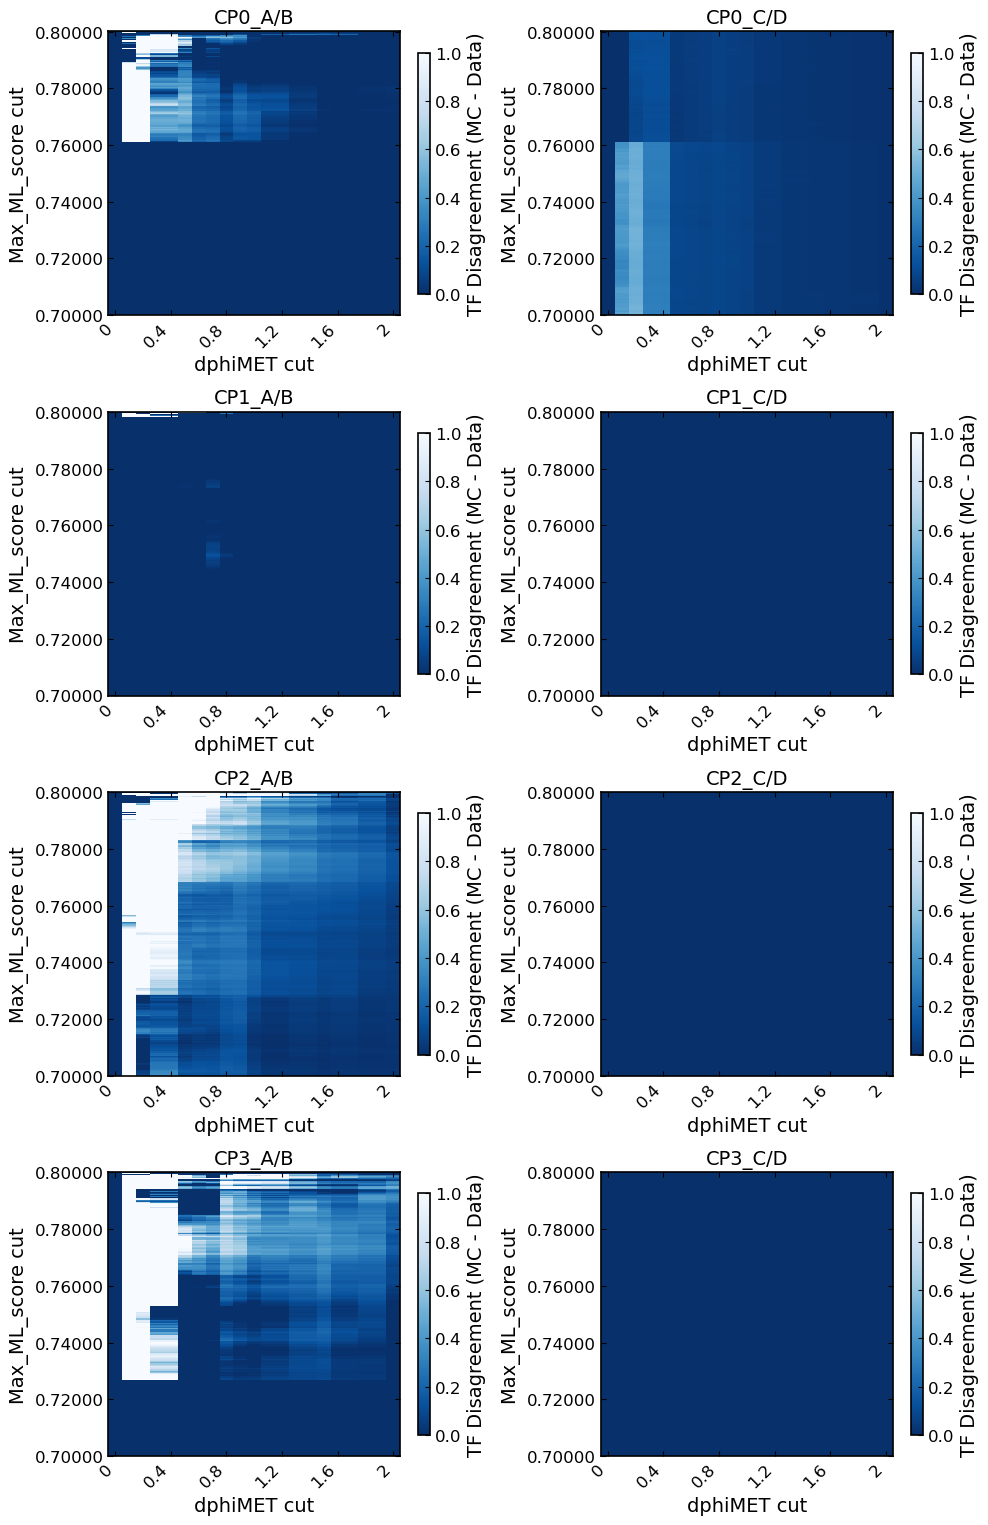

In [61]:
import matplotlib.ticker as mtick
def pick_ticks(vals, n=6):
    vals = np.asarray(list(vals), dtype=float)
    if len(vals) <= n:
        return vals
    idx = np.unique(np.round(np.linspace(0, len(vals)-1, n)).astype(int))
    idx[0] = 0
    idx[-1] = len(vals) - 1
    return vals[idx]

def edges_from_centers(c):
    c = np.asarray(c, dtype=float)
    d = np.diff(c)
    e = np.empty(len(c) + 1)
    e[1:-1] = c[:-1] + d / 2
    e[0]  = c[0]  - d[0] / 2
    e[-1] = c[-1] + d[-1] / 2
    return e

plotlim_xlo = 0.0
plotlim_xup = 2
plotlim_ylo = 0.7
plotlim_yup = 0.8

fig, axes = plt.subplots(4, 2, figsize=(10, 16))
axes = axes.flatten()

X = tf_disagreements_n

for ax, region in zip(axes, X.keys()):

    X_b = X[region]
    X_b = X_b.loc[plotlim_xlo:plotlim_xup, plotlim_ylo:plotlim_yup]
    X_b = X_b.fillna(0)

    x = X_b.index.to_numpy(dtype=float)
    y = X_b.columns.to_numpy(dtype=float)

    x_edges = edges_from_centers(x)
    y_edges = edges_from_centers(y)

    C = X_b.T.to_numpy()   # (Ny, Nx)
    absmax = np.nanmax(np.abs(C))

    pcm = ax.pcolormesh(
        x_edges, y_edges, C,
        cmap="Blues_r",
        vmin=0,
        vmax=1,
        shading="flat"
    )

    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))

    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()],
                       rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.3f}" for v in ax.get_yticks()])

    ax.set_xlabel(f'dphiMET cut')
    ax.set_ylabel(f'Max_ML_score cut')
    ax.set_title(region)

    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))

    cbar = fig.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel("TF Disagreement (MC - Data)")

# fig.suptitle(SAMPLE, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [62]:
xcut = 1.5
ycut = 0.799
for k, v in tf_disagreements_n.items():
    print(k, ': ', v.loc[xcut, ycut])

CP0_A/B :  0.2169602546995555
CP0_C/D :  0.017985626442533542
CP1_A/B :  -0.2415791146671724
CP1_C/D :  -0.022889405127385132
CP2_A/B :  0.42425393670336997
CP2_C/D :  -0.03921240430539408
CP3_A/B :  0.5892913483477129
CP3_C/D :  -0.13329322068989824
